# FIT5196 Assessment 1 - Task 5 focused EDA

**Group:** Group050  
**Team members:** Xingao Zhan (36354775); Yu Wang (26900867); Keshu Zhang (36436763); Qingzhuo Zhao (26662841)  
**Scope of this notebook version:** Keshu's assessed **Figure 7** and **Figure 8**, based on the standardised `product_reviews` and `products` outputs.

The contribution follows the workflow allocation exactly: Figure 7 examines review/text behaviour across rating and language groups, and Figure 8 compares review outcomes across product categories while making review volume visible. Task 6 findings and machine-learning questions are intentionally outside this file.


## 0. Configuration, loading and grain/join checks

The path detection supports running this notebook from either `Group050_A1` or the assignment root. The checks confirm one row per `review_id` and `product_id`, complete Product Review foreign keys, and a many-to-one join that retains exactly one row per canonical review.


In [1]:
from pathlib import Path
import os
import tempfile

# Keep Matplotlib's cache in a writable temporary location.
os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "group050-matplotlib-cache"),
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print


# USAGE:
#   Run this configuration cell before Figures 7 and 8.
# REASON:
#   Both figures require the final standardised tables and checked grains; the
#   relative search avoids student-specific absolute paths.
# EXPECTED RESULT:
#   `products`, `product_reviews`, and `review_product_analysis` are available,
#   with 0 orphan product IDs and no review-row multiplication after the join.
GROUP_ID = "Group050"
PRODUCT_FILE = f"{GROUP_ID}_products_standardised.csv"
REVIEW_FILE = f"{GROUP_ID}_product_reviews_standardised.csv"

candidate_output_dirs = [
    Path.cwd() / "outputs",
    Path.cwd() / "Group050_A1" / "outputs",
    Path.cwd().parent / "Group050_A1" / "outputs",
]

for candidate_output_dir in candidate_output_dirs:
    if (
        (candidate_output_dir / PRODUCT_FILE).is_file()
        and (candidate_output_dir / REVIEW_FILE).is_file()
    ):
        OUTPUT_DIR = candidate_output_dir.resolve()
        PROJECT_DIR = OUTPUT_DIR.parent
        break
else:
    raise FileNotFoundError(
        "Could not locate the Product and Product Review standardised outputs. "
        "Run the completed Task 4 solution before this EDA notebook."
    )

FIGURE_DIR = PROJECT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

products = pd.read_csv(
    OUTPUT_DIR / PRODUCT_FILE,
    keep_default_na=False,
    encoding="utf-8",
)
product_reviews = pd.read_csv(
    OUTPUT_DIR / REVIEW_FILE,
    keep_default_na=False,
    encoding="utf-8",
)

for numeric_column in ["unit_price"]:
    products[numeric_column] = pd.to_numeric(
        products[numeric_column],
        errors="raise",
    )

for numeric_column in [
    "rating",
    "helpful_votes",
    "review_length_chars",
    "review_word_count",
]:
    product_reviews[numeric_column] = pd.to_numeric(
        product_reviews[numeric_column],
        errors="raise",
    )

if not pd.api.types.is_bool_dtype(
    product_reviews["contains_non_latin_script"]
):
    boolean_map = {"True": True, "False": False}
    invalid_boolean_values = (
        set(product_reviews["contains_non_latin_script"]) - set(boolean_map)
    )
    if invalid_boolean_values:
        raise ValueError(
            "Unexpected contains_non_latin_script values: "
            f"{sorted(invalid_boolean_values)}"
        )
    product_reviews["contains_non_latin_script"] = (
        product_reviews["contains_non_latin_script"].map(boolean_map)
    )

assert products["product_id"].notna().all()
assert product_reviews[["review_id", "product_id"]].notna().all().all()
assert products["product_id"].is_unique, (
    "products must be one row per product_id"
)
assert product_reviews["review_id"].is_unique, (
    "product_reviews must be one row per review_id"
)

product_lookup = products[
    ["product_id", "category", "brand", "unit_price"]
].copy()
orphan_product_ids = (
    set(product_reviews["product_id"]) - set(product_lookup["product_id"])
)
assert not orphan_product_ids, (
    "Some Product Review product_id values do not resolve to products"
)

review_product_analysis = product_reviews.merge(
    product_lookup,
    on="product_id",
    how="left",
    validate="many_to_one",
    indicator=True,
)

assert review_product_analysis["_merge"].eq("both").all()
assert len(review_product_analysis) == len(product_reviews)
assert review_product_analysis["review_id"].is_unique
review_product_analysis = review_product_analysis.drop(columns="_merge")

join_check = pd.DataFrame(
    {
        "check": [
            "products rows / unique product_id",
            "product_reviews rows / unique review_id",
            "orphan Product Review product_id values",
            "rows after validated many-to-one join",
            "review rows multiplied by join",
        ],
        "observed": [
            f"{len(products):,} / {products['product_id'].nunique():,}",
            (
                f"{len(product_reviews):,} / "
                f"{product_reviews['review_id'].nunique():,}"
            ),
            len(orphan_product_ids),
            f"{len(review_product_analysis):,}",
            len(review_product_analysis) - len(product_reviews),
        ],
        "status": ["PASS"] * 5,
    }
)

display(join_check)
print(f"Output directory: {OUTPUT_DIR}")
print(f"Figure directory: {FIGURE_DIR}")


                                     check       observed status
0        products rows / unique product_id  1,000 / 1,000   PASS
1  product_reviews rows / unique review_id  7,000 / 7,000   PASS
2  orphan Product Review product_id values              0   PASS
3    rows after validated many-to-one join          7,000   PASS
4           review rows multiplied by join              0   PASS
Output directory: .\outputs
Figure directory: .\figures


### Figure 7: Review rating and text behaviour

**Analytical question:** How do review length and helpful votes vary across rating and language groups?  
**Observation unit:** One canonical Product Review.  
**Denominator:** All **7,000** rows in `product_reviews`: **6,311 English** reviews and **689 non-English** reviews. Each rating-language point uses the number of reviews reported in the summary table.  
**Tables used:** `product_reviews` only.  
**Join keys:** No join. `review_id` is the checked primary key.  
**Join multiplication check:** Not applicable; the analysis stays at one row per canonical review.  
**Chart choice:** Two coordinated point-and-IQR panels compare the median and middle 50% of character length and helpful votes across the five ordered rating groups, segmented by the structured `language_code`. This shows both centre and spread without hiding unequal group sizes.  
**Result:** English median review length declines from **974 characters at 1 star** to **905 at 5 stars**, while non-English medians range from **753 to 903 characters** and are not monotonic. Median helpful votes remain comparatively similar—between **42 and 50**—across all rating-language groups. The figure therefore shows clearer variation in text length than in helpful-vote behaviour.  
**Material limitation:** English reviews dominate the denominator, and the non-English label combines several languages with different writing systems. Character counts are not perfectly comparable across scripts, while helpful votes also depend on review exposure and age, which are unavailable here. The pattern is descriptive and does not establish that rating or language causes review length or helpfulness.


   rating language_group  reviews  ...  median_helpful  q1_helpful  q3_helpful
0       1        English      499  ...            42.0        23.0        66.5
1       1    Non-English       55  ...            43.0        17.5        68.5
2       2        English      544  ...            42.0        19.0        67.0
3       2    Non-English       68  ...            49.5        20.0        67.0
4       3        English     1112  ...            45.0        22.0        66.0
5       3    Non-English      123  ...            45.0        25.5        64.0
6       4        English     2082  ...            45.0        21.0        67.8
7       4    Non-English      240  ...            44.0        22.0        68.2
8       5        English     2074  ...            46.0        22.0        67.0
9       5    Non-English      203  ...            44.0        21.5        66.0

[10 rows x 9 columns]
Saved: .\figures\Figure 7.png
Group050_EDA_Keshu.ipynb:cell-4:145: UserWarning: FigureCanvasAgg is non-inter

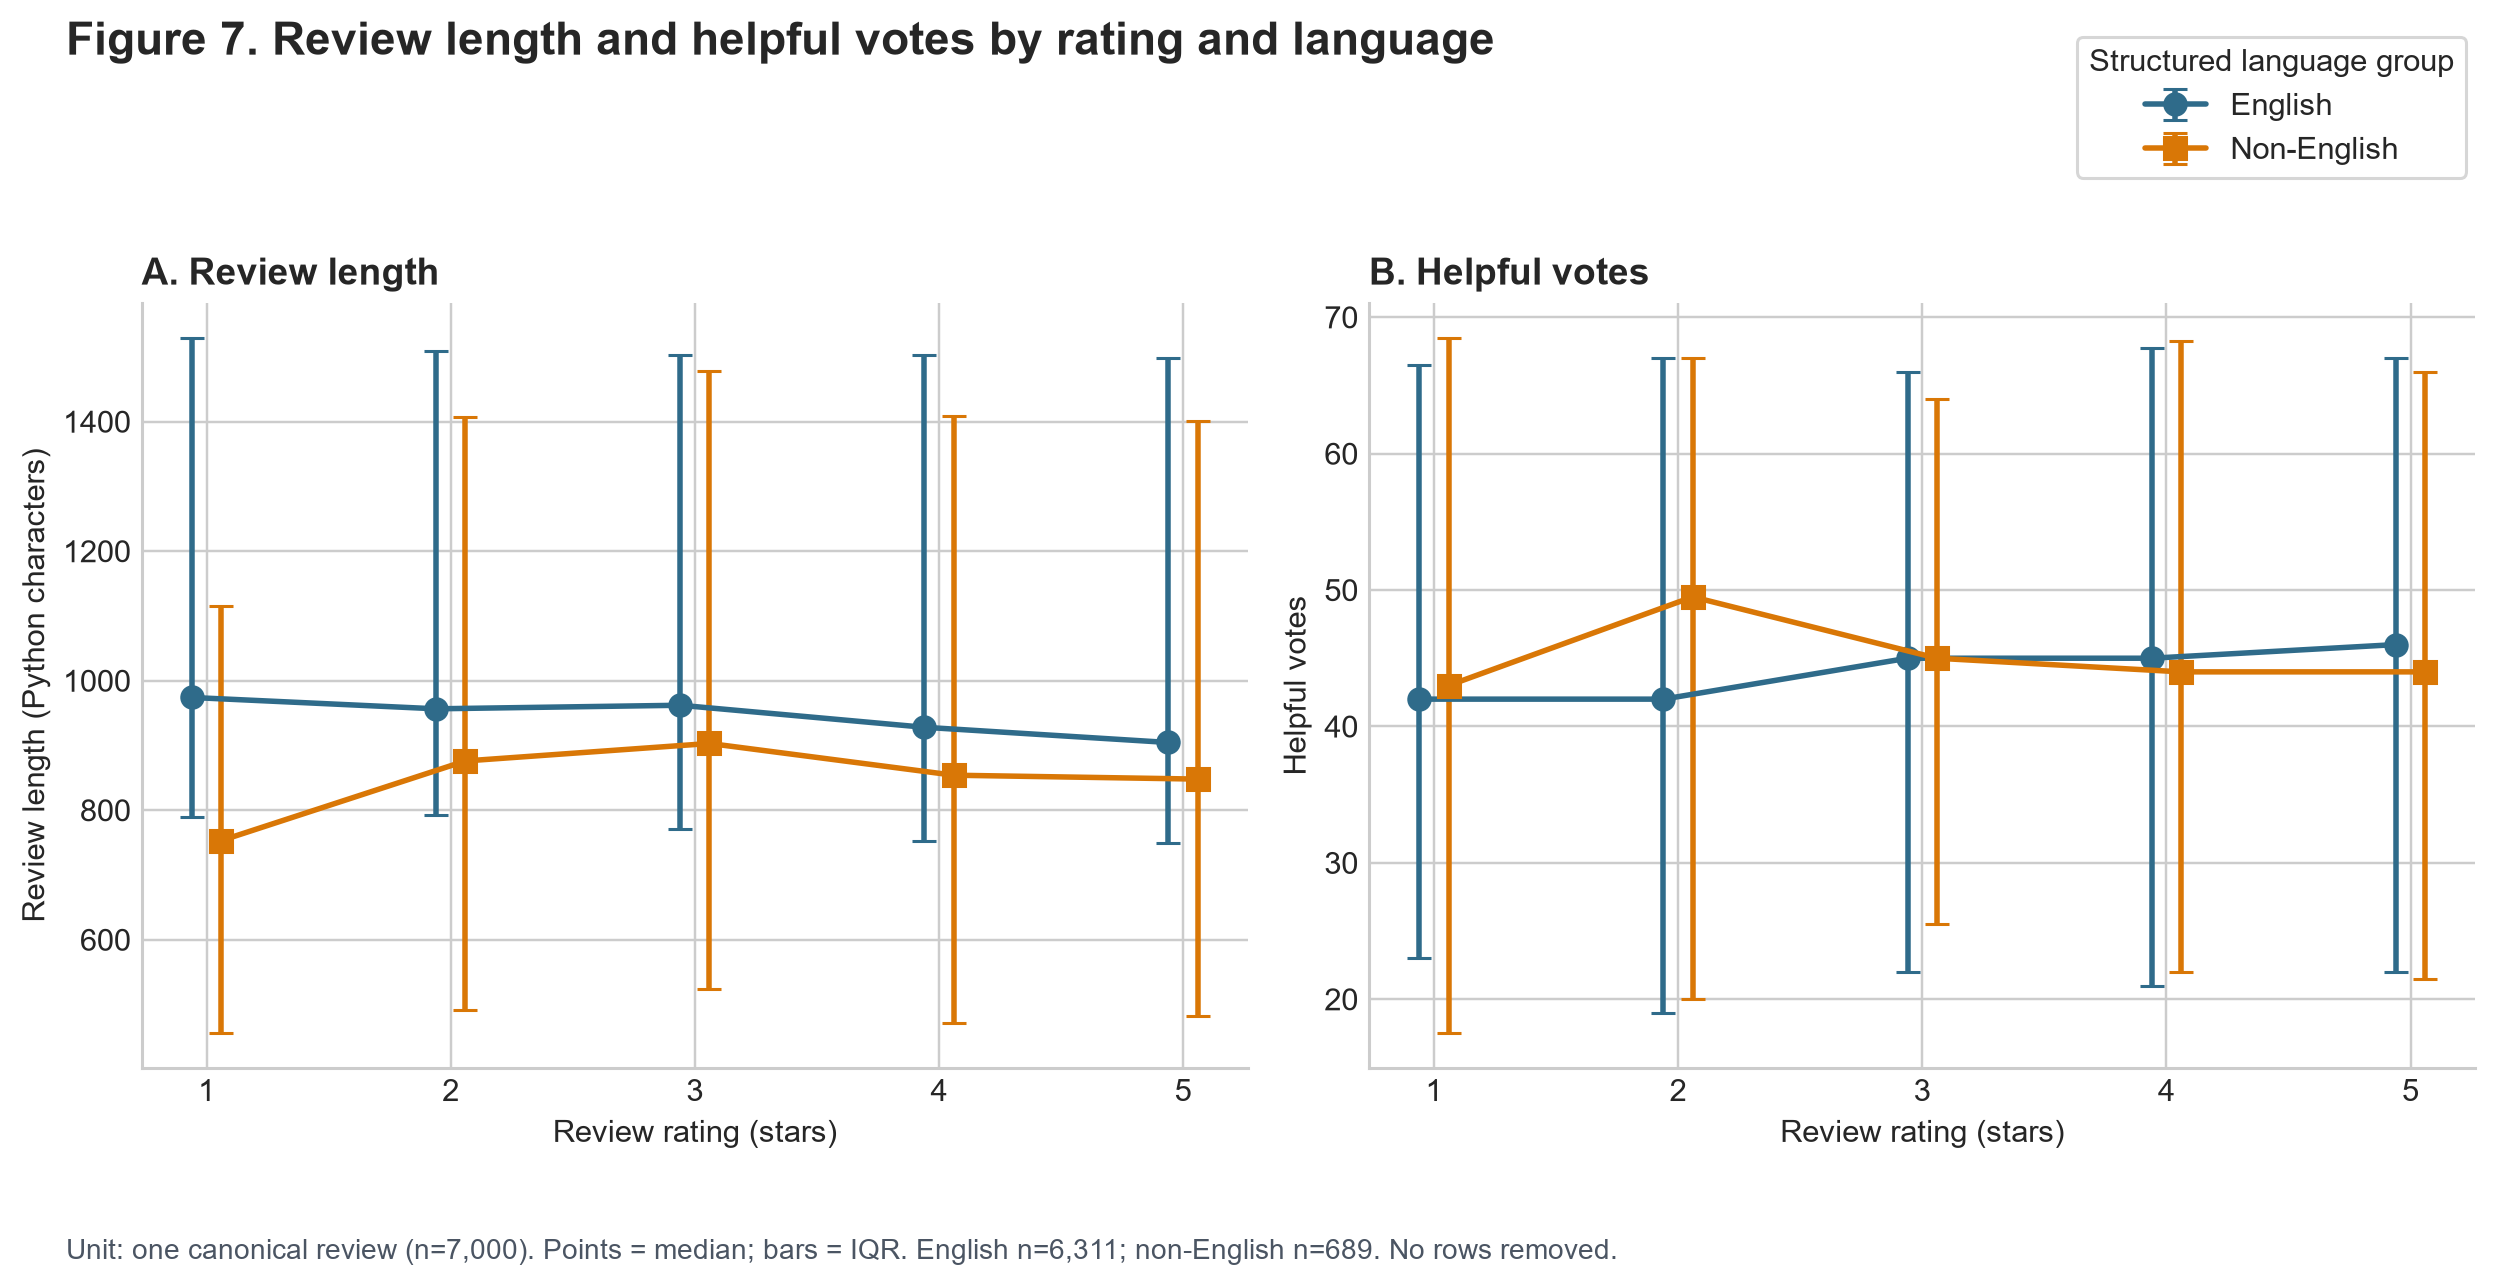

In [2]:
# USAGE:
#   Run after the configuration cell to reproduce assessed Figure 7.
# REASON:
#   The workflow assigns review length/helpfulness across rating or language
#   groups to Figure 7; medians and IQRs are robust to skewed text lengths.
# EXPECTED RESULT:
#   A two-panel assessed figure and a data-derived summary at one-review grain,
#   saved as `figures/Figure 7.png` without filtering any canonical review.
review_text_analysis = product_reviews.copy()
review_text_analysis["language_group"] = np.where(
    review_text_analysis["language_code"].eq("en"),
    "English",
    "Non-English",
)

rating_language_summary = (
    review_text_analysis.groupby(
        ["rating", "language_group"],
        observed=True,
    )
    .agg(
        reviews=("review_id", "size"),
        median_length=("review_length_chars", "median"),
        q1_length=(
            "review_length_chars",
            lambda values: values.quantile(0.25),
        ),
        q3_length=(
            "review_length_chars",
            lambda values: values.quantile(0.75),
        ),
        median_helpful=("helpful_votes", "median"),
        q1_helpful=(
            "helpful_votes",
            lambda values: values.quantile(0.25),
        ),
        q3_helpful=(
            "helpful_votes",
            lambda values: values.quantile(0.75),
        ),
    )
    .reset_index()
    .sort_values(["rating", "language_group"])
)

assert int(rating_language_summary["reviews"].sum()) == len(product_reviews)
display(rating_language_summary.round(1))

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.8), sharex=True)

language_styles = {
    "English": {"color": "#2F6B8A", "marker": "o", "offset": -0.06},
    "Non-English": {"color": "#D97706", "marker": "s", "offset": 0.06},
}

for language_group, style in language_styles.items():
    group = (
        rating_language_summary.loc[
            rating_language_summary["language_group"].eq(language_group)
        ]
        .set_index("rating")
        .reindex([1, 2, 3, 4, 5])
    )
    x_values = np.arange(1, 6) + style["offset"]

    axes[0].errorbar(
        x_values,
        group["median_length"],
        yerr=np.vstack(
            [
                group["median_length"] - group["q1_length"],
                group["q3_length"] - group["median_length"],
            ]
        ),
        color=style["color"],
        marker=style["marker"],
        markersize=7,
        linewidth=1.8,
        capsize=4,
        label=language_group,
    )
    axes[1].errorbar(
        x_values,
        group["median_helpful"],
        yerr=np.vstack(
            [
                group["median_helpful"] - group["q1_helpful"],
                group["q3_helpful"] - group["median_helpful"],
            ]
        ),
        color=style["color"],
        marker=style["marker"],
        markersize=7,
        linewidth=1.8,
        capsize=4,
        label=language_group,
    )

axes[0].set_title("A. Review length", loc="left", fontweight="bold")
axes[0].set_ylabel("Review length (Python characters)")
axes[1].set_title("B. Helpful votes", loc="left", fontweight="bold")
axes[1].set_ylabel("Helpful votes")

for axis in axes:
    axis.set_xlabel("Review rating (stars)")
    axis.set_xticks([1, 2, 3, 4, 5])
    axis.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Figure 7. Review length and helpful votes by rating and language",
    x=0.07,
    ha="left",
    fontsize=15,
    fontweight="bold",
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.97, 0.98),
    frameon=True,
    title="Structured language group",
)
fig.text(
    0.07,
    0.01,
    (
        "Unit: one canonical review (n=7,000). Points = median; bars = IQR. "
        "English n=6,311; non-English n=689. No rows removed."
    ),
    fontsize=9,
    color="#4B5563",
)
fig.tight_layout(rect=[0.04, 0.07, 0.98, 0.88])

figure_7_path = FIGURE_DIR / "Figure 7.png"
fig.savefig(
    figure_7_path,
    dpi=220,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()
print(f"Saved: {figure_7_path}")


### Figure 8: Product category and review outcomes

**Analytical question:** How do review ratings differ across product categories, and does review volume affect the apparent category result?  
**Observation unit:** One canonical Product Review, classified by its matched Product category.  
**Denominator:** All **7,000** canonical reviews. Category denominators range from **666 to 721 reviews** and are displayed beside every estimate.  
**Tables used:** `product_reviews` and `products`.  
**Join keys:** `product_reviews.product_id` → `products.product_id`.  
**Join multiplication check:** `products.product_id` is unique; `merge(validate='many_to_one')` retains **7,000 reviews before and after**, with **0 orphan keys** and **0 multiplied rows**.  
**Chart choice:** A horizontal dot-and-95%-CI plot makes category means and uncertainty directly comparable. Marker area and text labels show review volume, while the dashed reference line shows the overall review mean.  
**Result:** Mean rating ranges from **3.29 for Audio** to **4.20 for Accessory**, a gap of approximately **0.91 stars**. Review counts are comparatively balanced across categories, and their correlation with category mean rating is weak (**Pearson r = 0.156**), so the visible category ordering is not explained simply by larger review volume.  
**Material limitation:** Category means are descriptive and may reflect differences in product mix, reviewer selection, customer expectations, review timing or unmeasured confounders. Reviews are not a random sample of all purchasers, and weighting each review equally means products with more reviews contribute more to their category estimate.


             category  reviews  ...  ci95_low  ci95_high
0               Audio      707  ...     3.209      3.374
1          Networking      699  ...     3.225      3.390
2              Laptop      691  ...     3.244      3.408
3              Gaming      686  ...     3.324      3.481
4              Tablet      705  ...     3.338      3.491
5          Smartphone      696  ...     3.940      4.129
6            Wearable      716  ...     4.004      4.183
7          Smart Home      713  ...     4.046      4.226
8  Home Entertainment      666  ...     4.058      4.242
9           Accessory      721  ...     4.109      4.285

[10 rows x 7 columns]
Pearson correlation between category review count and mean rating: 0.156
Saved: .\figures\Figure 8.png
Group050_EDA_Keshu.ipynb:cell-6:132: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


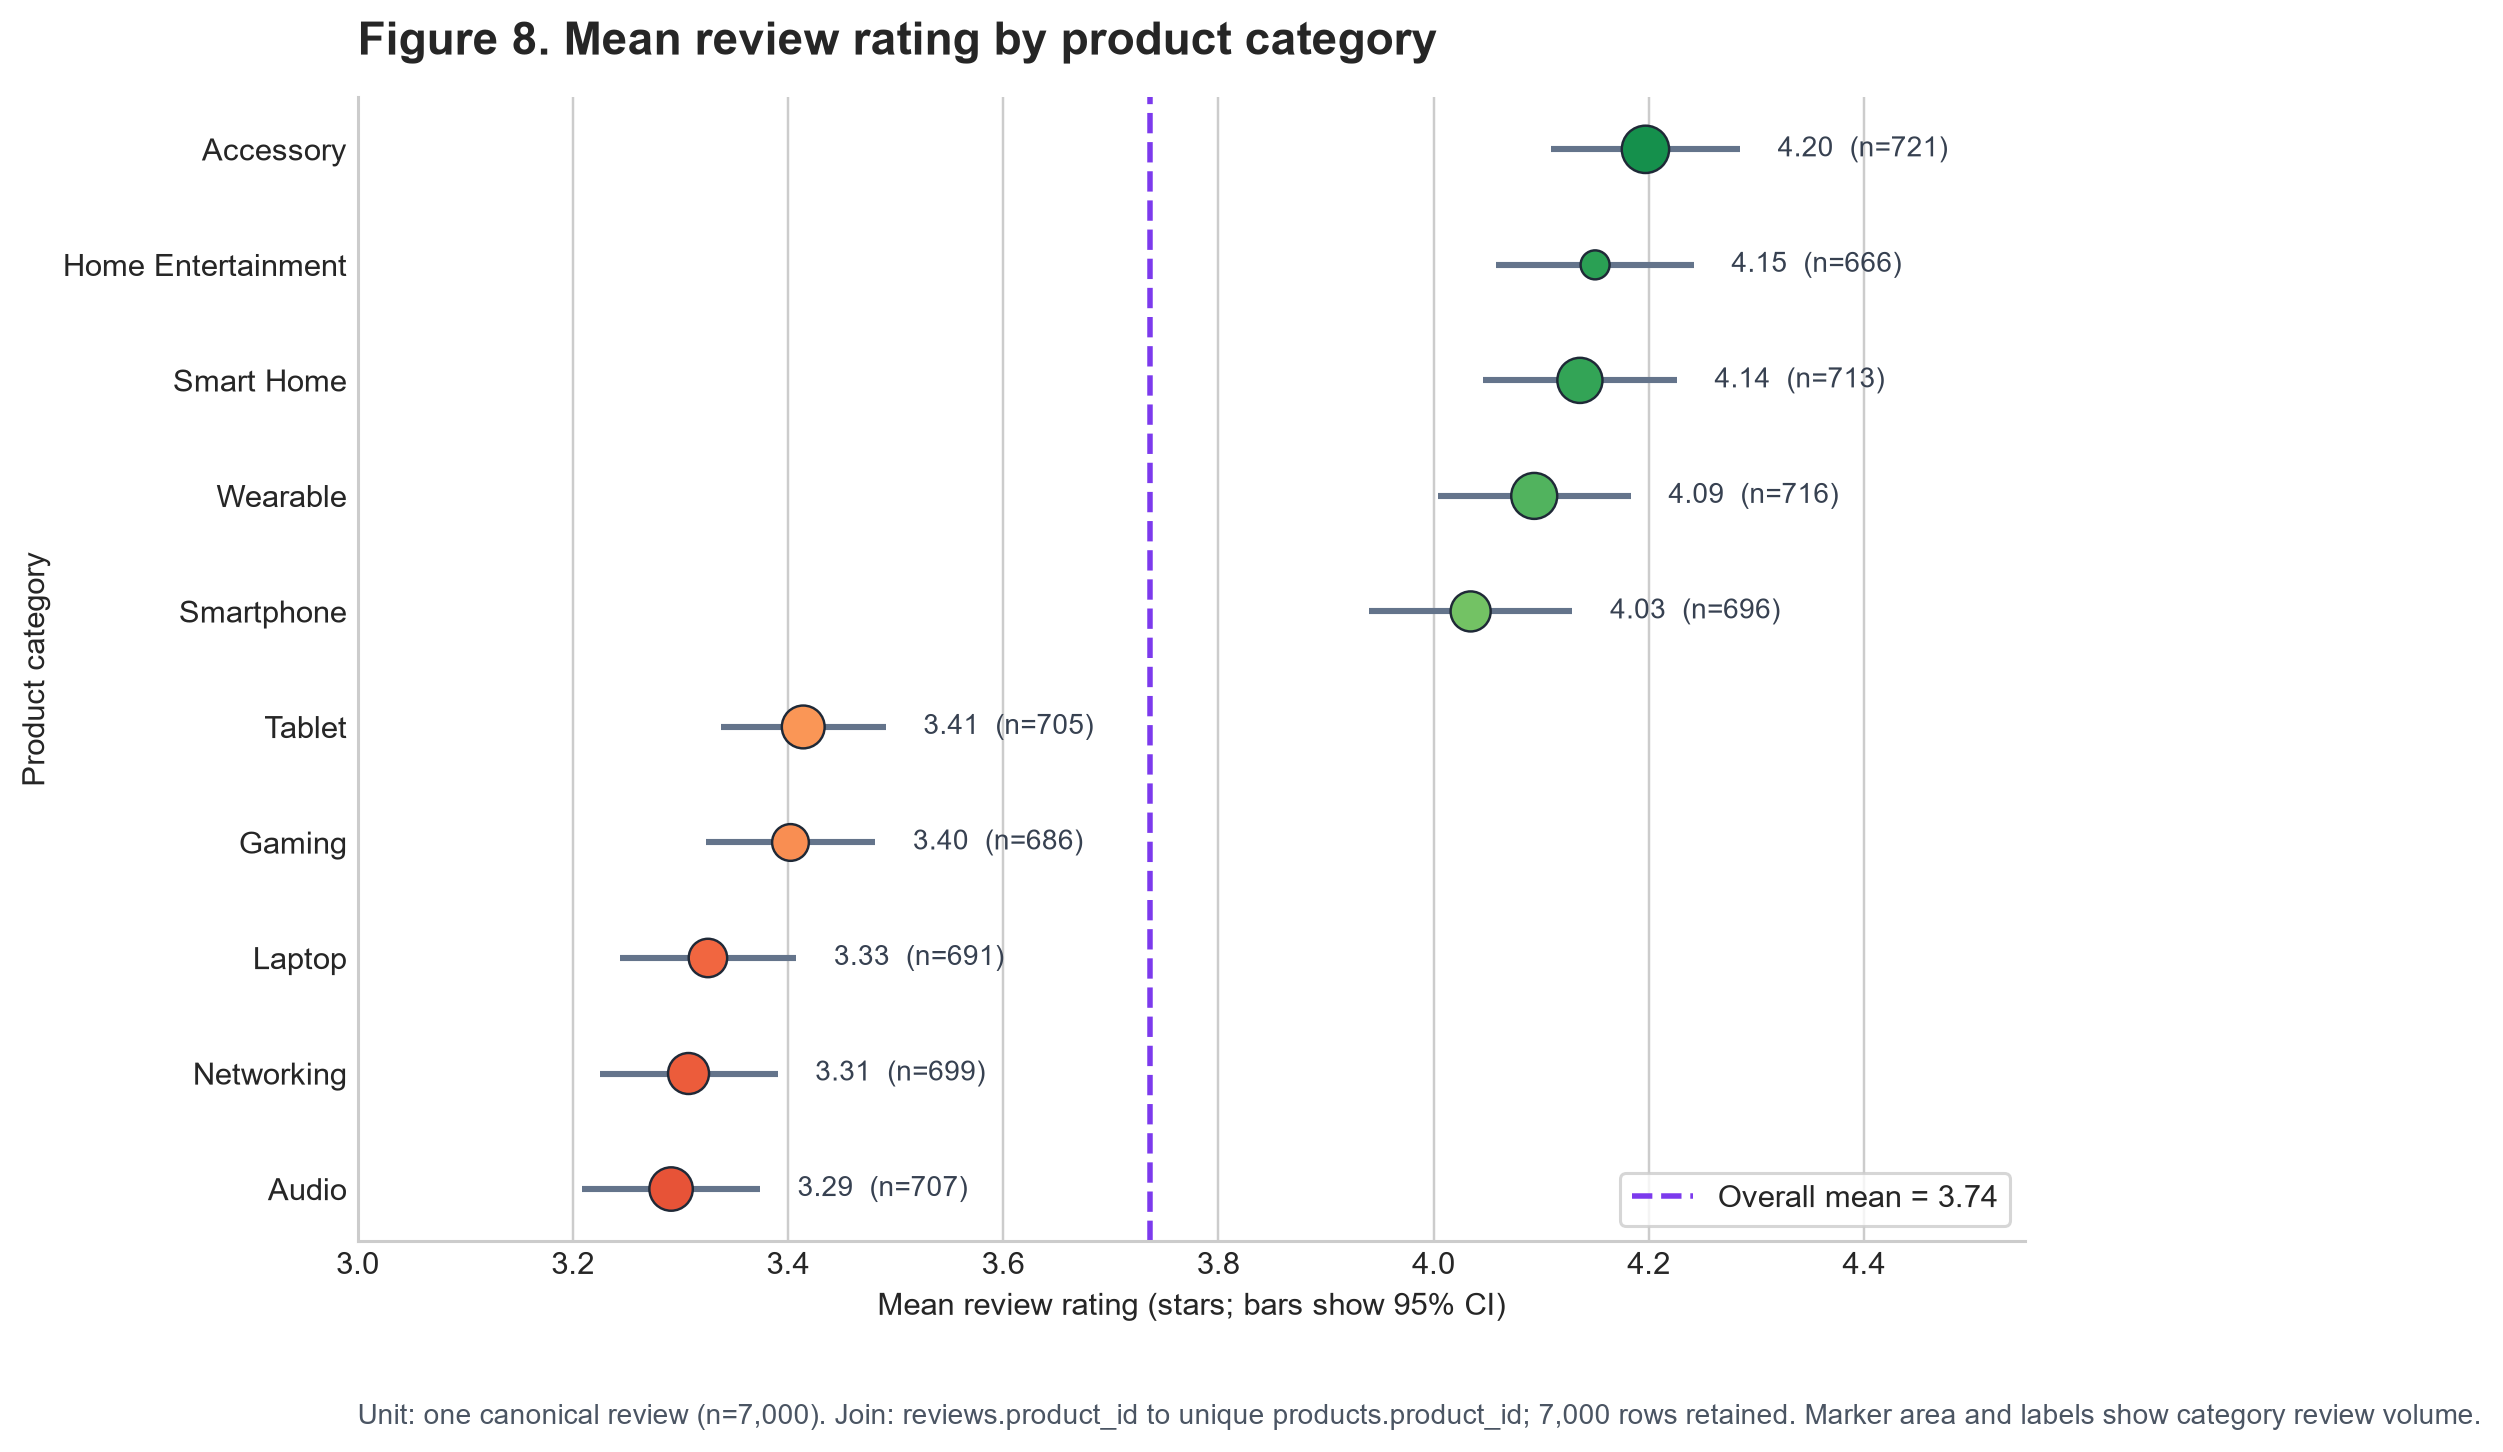

In [3]:
# USAGE:
#   Run after the configuration cell to reproduce assessed Figure 8.
# REASON:
#   The workflow asks for category rating differences with review volume made
#   visible; a validated many-to-one join preserves the one-review denominator.
# EXPECTED RESULT:
#   One category estimate with a 95% CI and sample size label for each of the
#   ten categories, saved as `figures/Figure 8.png`.
category_review_summary = (
    review_product_analysis.groupby("category", observed=True)["rating"]
    .agg(reviews="size", mean_rating="mean", rating_sd="std")
    .reset_index()
)
category_review_summary["standard_error"] = (
    category_review_summary["rating_sd"]
    / np.sqrt(category_review_summary["reviews"])
)
category_review_summary["ci95_low"] = (
    category_review_summary["mean_rating"]
    - 1.96 * category_review_summary["standard_error"]
)
category_review_summary["ci95_high"] = (
    category_review_summary["mean_rating"]
    + 1.96 * category_review_summary["standard_error"]
)
category_review_summary = category_review_summary.sort_values(
    "mean_rating",
    kind="stable",
).reset_index(drop=True)

overall_mean_rating = review_product_analysis["rating"].mean()
volume_rating_correlation = category_review_summary["reviews"].corr(
    category_review_summary["mean_rating"]
)

assert int(category_review_summary["reviews"].sum()) == len(
    review_product_analysis
)
display(category_review_summary.round(3))
print(
    "Pearson correlation between category review count and mean rating: "
    f"{volume_rating_correlation:.3f}"
)

fig, ax = plt.subplots(figsize=(10.8, 6.7))
y_positions = np.arange(len(category_review_summary))

ax.hlines(
    y=y_positions,
    xmin=category_review_summary["ci95_low"],
    xmax=category_review_summary["ci95_high"],
    color="#64748B",
    linewidth=2.0,
    zorder=1,
)

minimum_volume = category_review_summary["reviews"].min()
maximum_volume = category_review_summary["reviews"].max()
volume_span = max(maximum_volume - minimum_volume, 1)
marker_sizes = 90 + (
    (category_review_summary["reviews"] - minimum_volume)
    / volume_span
) * 150

points = ax.scatter(
    category_review_summary["mean_rating"],
    y_positions,
    s=marker_sizes,
    c=category_review_summary["mean_rating"],
    cmap="RdYlGn",
    vmin=3.1,
    vmax=4.3,
    edgecolor="#1F2937",
    linewidth=0.8,
    zorder=2,
)

for y_position, row in category_review_summary.iterrows():
    ax.text(
        row["ci95_high"] + 0.035,
        y_position,
        f"{row['mean_rating']:.2f}  (n={int(row['reviews']):,})",
        va="center",
        fontsize=9,
        color="#374151",
    )

ax.axvline(
    overall_mean_rating,
    color="#7C3AED",
    linestyle="--",
    linewidth=1.8,
    label=f"Overall mean = {overall_mean_rating:.2f}",
)
ax.set_yticks(
    y_positions,
    category_review_summary["category"],
)
ax.set_xlim(3.0, 4.55)
ax.set_xlabel("Mean review rating (stars; bars show 95% CI)")
ax.set_ylabel("Product category")
ax.set_title(
    "Figure 8. Mean review rating by product category",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=14,
)
ax.legend(loc="lower right", frameon=True)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", visible=False)
ax.text(
    0,
    -0.16,
    (
        "Unit: one canonical review (n=7,000). Join: reviews.product_id to unique products.product_id; "
        "7,000 rows retained. Marker area and labels show category review volume."
    ),
    transform=ax.transAxes,
    fontsize=9,
    color="#4B5563",
)

fig.tight_layout()
figure_8_path = FIGURE_DIR / "Figure 8.png"
fig.savefig(
    figure_8_path,
    dpi=220,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()
print(f"Saved: {figure_8_path}")


## Handoff note for the team notebook

These are the two assessed Task 5 visualisations allocated to the `products` / `product_reviews` contribution. When merging, preserve the **Figure 7** and **Figure 8** labels, the analytical-question blocks, and the grain/join evidence. The final team notebook should retain only 6–8 assessed figures in total and should confirm that the combined set covers all six required analytical categories, at least four output tables, and at least two correct relational joins.

Task 6 is not included here. Findings 9–10 and MLQ4–5 remain a separate future contribution under the workflow allocation.
